[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Yel1owHatGuy/Machine-Learning-2025L/blob/master/Homeworks/lab2_hw.ipynb)

# **Homework Assignment: EM Clustering in 2D**
-------------------------------

You have seen how the **Expectation-Maximization (EM)** algorithm can fit a Gaussian Mixture Model (GMM) to a 2D dataset. You should now explore:

## **Primary Question**

**How can we visualize the *decision boundary* for attributing a *new* (unlabeled) point to one of the GMM clusters?**  

In other words, given a 2D data distribution modeled by EM, think of a way to clearly show (on a plot) *which* cluster a point would be assigned to (or which cluster has the highest responsibility (posterior probability) for that point)?  

The plot should comprehensively cover the entire visible region, ensuring that for any point on the plot, it is immediately evident which cluster it would belong to. You can plot **lines** separating clusters or use a **color map** showing each point's "most likely cluster" (use at least 1000 points).

You can illustrate your approach with **the same** 2D dataset that we used in class, or you can find another suitable 2D dataset, it's up to you. Note however, that having 3 clusters enhances the clarity of the visualization—while 2 clusters result in overly simple boundaries, using 4 or more clusters can make the entire plot difficult to interpret. Try to choose a dataset with 3 clusters.

Discuss any irregularities observed in the resulting plot. If a decision boundary suggests that a region should be attributed to a cluster in a counterintuitive way (we saw it in class!), provide an explanation for why this might occur. It may be also an indication you have a bug in your code.

## **Secondary Question**

**If we *didn't know* the number of clusters in advance, how could we decide on a suitable $K$ for the clustering algorithm?**  

You would need an evaluation metrics, right? Experiment with inertia and silhoutte scores (and other metrics, if you'd like) and show the resulting plots.

You can illustrate your approach with **the same** dataset as in the primary question by trying different values of $K$. Or you can find another suitable dataset, it's up to you. Note, that the dataset doesn't need to be 2D in this task.


In [16]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(0)  # for reproducibility

mean1 = np.array([0.0, 0.0])
cov1 = np.array([[0.16, 0.0],
                 [0.0,  0.16]])
data1 = np.random.multivariate_normal(mean1, cov1, 600)

mean2 = np.array([0.8, 0.8])
cov2 = np.array([[0.04, 0.0],
                 [0.0,  0.04]])
data2 = np.random.multivariate_normal(mean2, cov2, 300)

mean3 = np.array([-0.8, 0.8])
cov3 = np.array([[0.04, 0.0],
                 [0.0,  0.04]])
data3 = np.random.multivariate_normal(mean3, cov3, 300)

data_X = np.vstack([data1, data2, data3])
N, d = data_X.shape

# ----------------------------------------------------------------------
# SECTION 2: Initialize EM for 3 Gaussian mixtures
# ----------------------------------------------------------------------
K = 3
np.random.seed(42)  # again for reproducibility

# Mixture weights, means, covariances
pi = np.ones(K) / K
mu = np.random.randn(K, d)
Sigma = np.array([np.eye(d) for _ in range(K)])
print(Sigma)
# ----------------------------------------------------------------------
# SECTION 3: Define functions for E-step & M-step
# ----------------------------------------------------------------------
def gaussian_pdf(x, mean, cov):
    """
    Compute multivariate Gaussian pdf value at x, given mean and cov.
    x is (d, ) vector, mean is (d, ), cov is (d, d).
    """
    d_ = len(x)
    det_cov = np.linalg.det(cov)
    inv_cov = np.linalg.inv(cov)
    norm_const = 1.0 / np.sqrt((2*np.pi)**d_ * det_cov)
    diff = x - mean
    exponent = -0.5 * (diff @ inv_cov @ diff.T)
    return norm_const * np.exp(exponent)

def e_step(data, pi, mu, Sigma):
    """
    E-step: compute the responsibilities resp[n, k] = p(z_n=k | x_n, theta).
    """
    N, _ = data.shape
    K = len(pi)
    resp = np.zeros((N, K))

    for n in range(N):
        for k in range(K):
            resp[n, k] = pi[k] * gaussian_pdf(data[n], mu[k], Sigma[k])
        resp[n, :] /= np.sum(resp[n, :])  # normalize

    return resp

def m_step(data, resp):
    """
    M-step: given responsibilities, update pi, mu, Sigma.
    """
    N, d_ = data.shape
    K = resp.shape[1]

    Nk = np.sum(resp, axis=0)  # shape (K,)

    # Update pi
    pi_new = Nk / N

    # Update mu
    mu_new = np.zeros((K, d_))
    for k in range(K):
        mu_new[k] = np.sum(resp[:, k].reshape(-1,1)*data, axis=0) / Nk[k]

    # Update Sigma
    Sigma_new = []
    for k in range(K):
        S_k = np.zeros((d_, d_))
        for n in range(N):
            diff = data[n] - mu_new[k]
            S_k += resp[n, k] * np.outer(diff, diff)
        S_k /= Nk[k]
        Sigma_new.append(S_k)
    Sigma_new = np.array(Sigma_new)

    return pi_new, mu_new, Sigma_new

[[[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]]


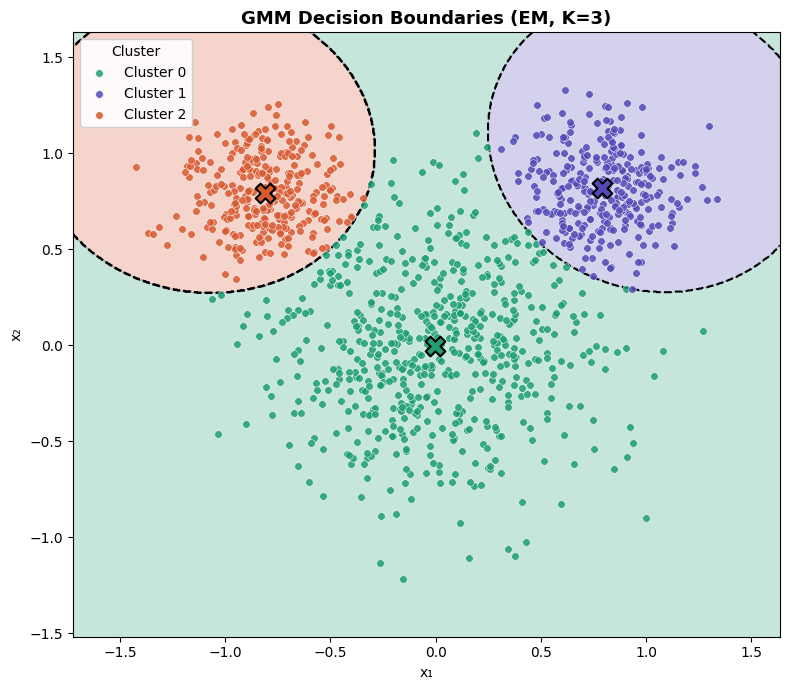

In [17]:
from matplotlib.colors import ListedColormap

for _ in range(60):
    resp = e_step(data_X, pi, mu, Sigma)
    pi, mu, Sigma = m_step(data_X, resp)

x_min, x_max = data_X[:, 0].min() - 0.3, data_X[:, 0].max() + 0.3
y_min, y_max = data_X[:, 1].min() - 0.3, data_X[:, 1].max() + 0.3

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000),
                     np.linspace(y_min, y_max, 1000))
grid = np.c_[xx.ravel(), yy.ravel()]

grid_resp = e_step(grid, pi, mu, Sigma)
Z = np.argmax(grid_resp, axis=1).reshape(xx.shape)


colors = ['#1D9E75', '#534AB7', '#D85A30']
cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(8, 7))

ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap, levels=[-0.5, 0.5, 1.5, 2.5])

ax.contour(xx, yy, Z, levels=[0.5, 1.5], colors='black',
           linewidths=1.5, linestyles='--')


labels_final = np.argmax(resp, axis=1)
for k in range(K):
    mask = labels_final == k
    ax.scatter(data_X[mask, 0], data_X[mask, 1],
               c=colors[k], edgecolors='white', linewidths=0.4,
               s=30, alpha=0.85, label=f'Cluster {k}', zorder=3)


for k in range(K):
    ax.scatter(mu[k, 0], mu[k, 1],
               marker='X', s=200, c=colors[k],
               edgecolors='black', linewidths=1.5, zorder=5)

ax.set_title('GMM Decision Boundaries (EM, K=3)', fontsize=13, fontweight='bold')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.legend(title='Cluster', framealpha=0.9)
plt.tight_layout()
plt.show()

Jak widać, mamy dwa mniejsze klastry oraz jeden duży, centralny. Mniejsze mają okrągłe, odcięte granice wewnątrz dużego zielonego klastra. Granice są okrągłe i izolują mniejsze klastry, ponieważ ich kowariancja jest zdecydowanie mniejsza niż klastra 0. Jest to spowodowane przez fakt, że GMM porównuje gęśtości prawdopodobieńśtwa, a nie odległości.

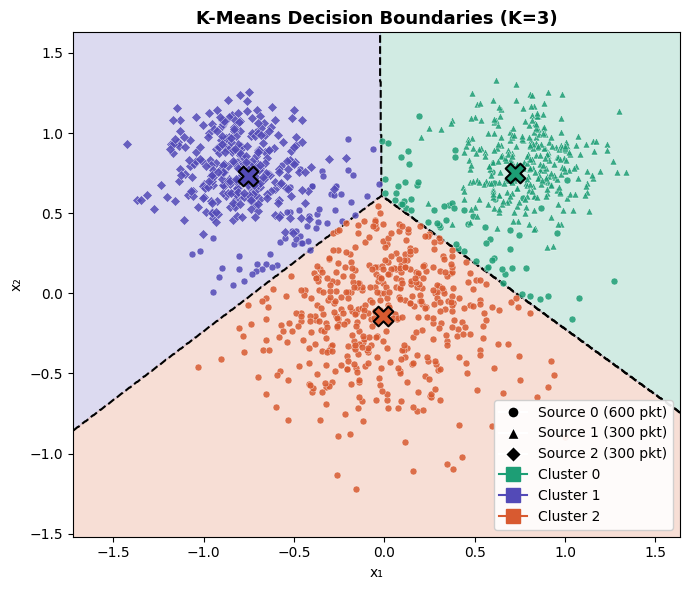

In [ ]:
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D


km_model = KMeans(n_clusters=3, random_state=42)
km_model.fit(data_X)
km_labels = km_model.labels_

x_min, x_max = data_X[:, 0].min() - 0.3, data_X[:, 0].max() + 0.3
y_min, y_max = data_X[:, 1].min() - 0.3, data_X[:, 1].max() + 0.3

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000),
                     np.linspace(y_min, y_max, 1000))
grid = np.c_[xx.ravel(), yy.ravel()]

Z = km_model.predict(grid).reshape(xx.shape)


colors = ['#1D9E75', '#534AB7', '#D85A30']
cmap = ListedColormap(colors)
markers = ['o', '^', 'D']
data_counts = [600, 300, 300]

fig, ax = plt.subplots(figsize=(7, 6))

ax.contourf(xx, yy, Z, alpha=0.2, cmap=cmap, levels=[-0.5, 0.5, 1.5, 2.5])


ax.contour(xx, yy, Z, levels=[0.5, 1.5], colors='black',
           linewidths=1.5, linestyles='--')

start = 0
for g in range(3):
    end = start + data_counts[g]
    chunk_labels = km_labels[start:end]
    for k in range(3):
        mask = chunk_labels == k
        ax.scatter(data_X[start:end][mask, 0],
                   data_X[start:end][mask, 1],
                   c=colors[k], marker=markers[g],
                   s=25, edgecolors='white', linewidths=0.3,
                   alpha=0.85, zorder=3)
    start = end


for k in range(3):
    ax.scatter(km_model.cluster_centers_[k, 0],
               km_model.cluster_centers_[k, 1],
               marker='X', s=200, c=colors[k],
               edgecolors='black', linewidths=1.5, zorder=5)


legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='k', markersize=8, label='Source 0 (600 pkt)'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='k', markersize=8, label='Source 1 (300 pkt)'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor='k', markersize=8, label='Source 2 (300 pkt)'),
    Line2D([0],[0], marker='s', color=colors[0], markersize=10, label='Cluster 0'),
    Line2D([0],[0], marker='s', color=colors[1], markersize=10, label='Cluster 1'),
    Line2D([0],[0], marker='s', color=colors[2], markersize=10, label='Cluster 2'),
]
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.9)

ax.set_title('K-Means Decision Boundaries (K=3)', fontsize=13, fontweight='bold')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
plt.tight_layout()
plt.show()

Teraz użyliśmy K-Means. Granice decyzyjnesą prostymi liniami, każdy punkt jest przypisywany do klastra o najbliższym centrum w sensie odległości euklidesowej. K-Means zakłada że wszystkie klastry mają jednakową, kowariancję, co w tym przypadku jest nieprawdą. Algorytm kradnie część punktów należących do klastra 2, przypisująć je do dwóch mniejszych. Dzieje się tak, ponieważ te punkty leżą bliżej centrum mniejszych zbiorów. W odróżnieniu od GMM, K-Means nie potrafi uwzględnić faktu że klastry 0 i 1 są znacznie bardziej "skupione" niż klaster 2. Efektem jest gorsza jakość klastryzacji na tym datasecie.

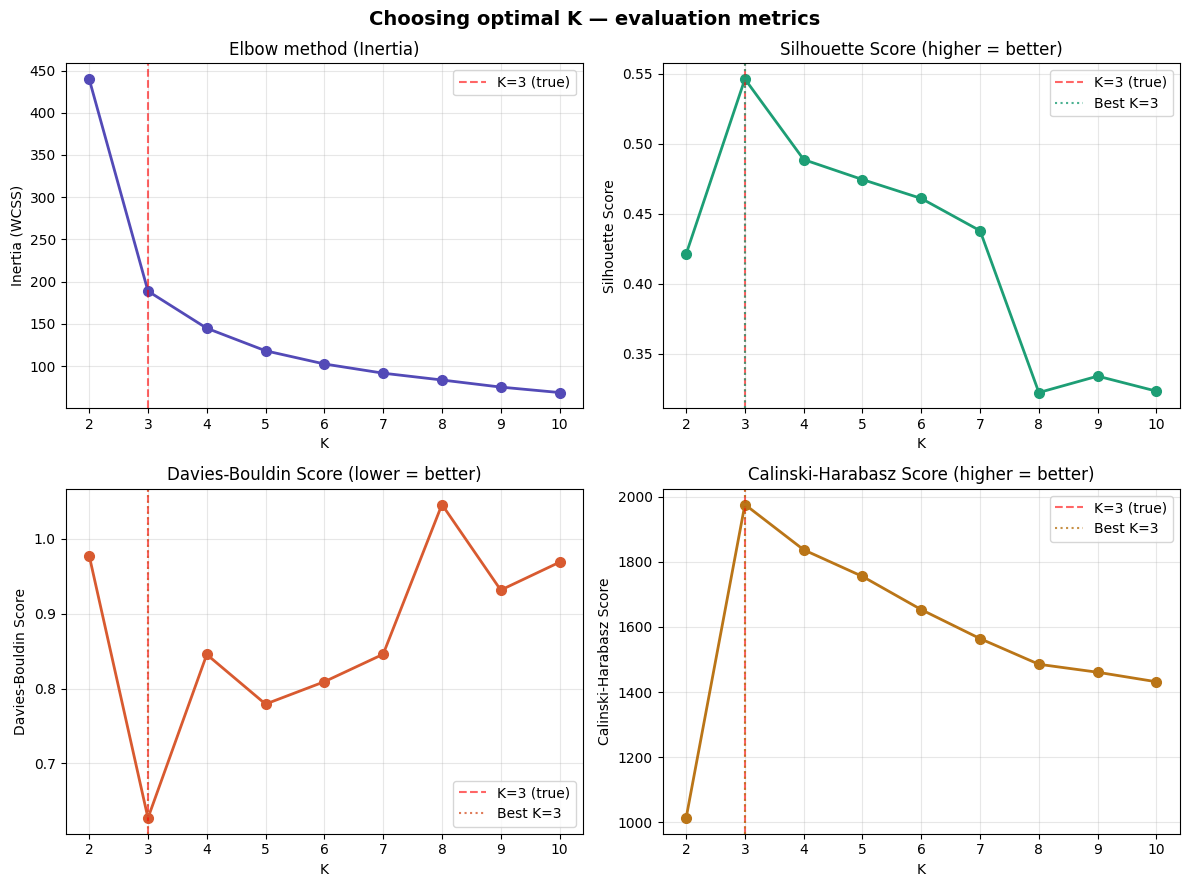

K | Inertia   | Silhouette | Davies-Bouldin | Calinski-Harabasz
-----------------------------------------------------------------
2 |     440.0 |     0.4213 |         0.9778 |            1013.1
3 |     188.8 |     0.5463 |         0.6270 |            1975.8
4 |     144.8 |     0.4888 |         0.8455 |            1836.7
5 |     118.1 |     0.4745 |         0.7793 |            1754.9
6 |     102.5 |     0.4610 |         0.8092 |            1653.0
7 |      91.6 |     0.4380 |         0.8459 |            1564.0
8 |      83.5 |     0.3224 |         1.0459 |            1485.2
9 |      75.1 |     0.3342 |         0.9316 |            1460.7
10 |      68.7 |     0.3234 |         0.9688 |            1431.5


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

K_range = range(2, 11)

inertias   = []
silhouettes = []
db_scores  = []
ch_scores  = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(data_X)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(data_X, labels))
    db_scores.append(davies_bouldin_score(data_X, labels))
    ch_scores.append(calinski_harabasz_score(data_X, labels))


fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Choosing optimal K — evaluation metrics', fontsize=14, fontweight='bold')

K_list = list(K_range)

axes[0,0].plot(K_list, inertias, 'o-', color='#534AB7', linewidth=2, markersize=7)
axes[0,0].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='K=3 (true)')
axes[0,0].set_title('Elbow method (Inertia)')
axes[0,0].set_xlabel('K')
axes[0,0].set_ylabel('Inertia (WCSS)')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(K_list, silhouettes, 'o-', color='#1D9E75', linewidth=2, markersize=7)
axes[0,1].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='K=3 (true)')
best_sil = K_list[np.argmax(silhouettes)]
axes[0,1].axvline(x=best_sil, color='#1D9E75', linestyle=':', alpha=0.8, label=f'Best K={best_sil}')
axes[0,1].set_title('Silhouette Score (higher = better)')
axes[0,1].set_xlabel('K')
axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

axes[1,0].plot(K_list, db_scores, 'o-', color='#D85A30', linewidth=2, markersize=7)
axes[1,0].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='K=3 (true)')
best_db = K_list[np.argmin(db_scores)]
axes[1,0].axvline(x=best_db, color='#D85A30', linestyle=':', alpha=0.8, label=f'Best K={best_db}')
axes[1,0].set_title('Davies-Bouldin Score (lower = better)')
axes[1,0].set_xlabel('K')
axes[1,0].set_ylabel('Davies-Bouldin Score')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(K_list, ch_scores, 'o-', color='#BA7517', linewidth=2, markersize=7)
axes[1,1].axvline(x=3, color='red', linestyle='--', alpha=0.6, label='K=3 (true)')
best_ch = K_list[np.argmax(ch_scores)]
axes[1,1].axvline(x=best_ch, color='#BA7517', linestyle=':', alpha=0.8, label=f'Best K={best_ch}')
axes[1,1].set_title('Calinski-Harabasz Score (higher = better)')
axes[1,1].set_xlabel('K')
axes[1,1].set_ylabel('Calinski-Harabasz Score')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


print("K | Inertia   | Silhouette | Davies-Bouldin | Calinski-Harabasz")
print("-" * 65)
for i, k in enumerate(K_list):
    print(f"{k} | {inertias[i]:9.1f} | {silhouettes[i]:10.4f} | {db_scores[i]:14.4f} | {ch_scores[i]:17.1f}")

Mamy kilka metryk, możemy zbadać ich zachowanie dla danego K, następnie wybrać te, które je maksymalizuje. W naszym przypadku K = 3 jasno wychodzi jako najlepsze.

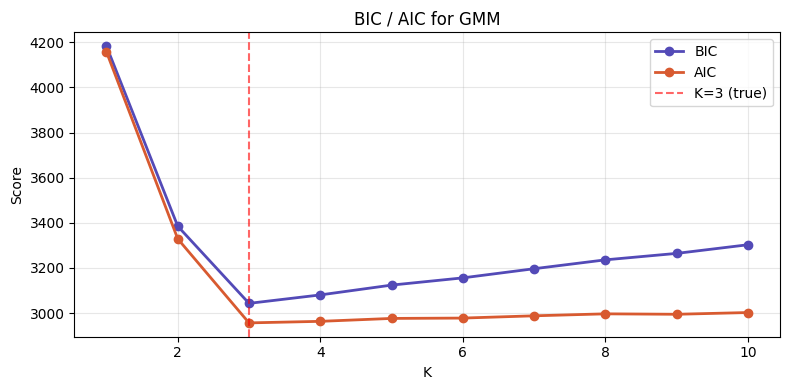

In [ ]:
from sklearn.mixture import GaussianMixture

K_range = range(1, 11)
bic_scores = []
aic_scores = [] 

for k in K_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          random_state=42, n_init=5)
    gmm.fit(data_X)
    bic_scores.append(gmm.bic(data_X))
    aic_scores.append(gmm.aic(data_X))

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), bic_scores, 'o-', color='#534AB7', label='BIC', linewidth=2)
plt.plot(list(K_range), aic_scores, 'o-', color='#D85A30', label='AIC', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.6, label='K=3 (true)')
plt.xlabel('K'); plt.ylabel('Score'); plt.title('BIC / AIC for GMM')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Gdy korzystamy z GMM i nie znamy K, mamy dwie możliwości. Możemy użyć metryki BIC, która penalizuje złożoność modelu: BIC = -2 · log-likelihood + k · log(N), bądź podejścia Bayesowskiego, BGMM, który maksymalizuje ELBO i wyłącza niepotrzebne klastry, ustawiając im wagę $\pi_{k} = 0$
